In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
I_1 = 0.1 # [kg.m^2]
I_2 = 5 # [kg.m^2]
c = 25 # [N.m/rad]

In [3]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
        A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
        t = np.linspace(0, time_span, 1000)
        theta_1 = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
        theta_2 = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [4]:
# Define an instance of the model
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)

In [5]:
# Define Initial Conditions
theta_0 = [1, -0.1] # Initial angular position
theta_dot_0 = [-2, 0.1] # Initial angular velocity
# Calculate solution
t, theta_1, theta_2 = S.simulate_time_response(initial_angle=theta_0, initial_velocity=theta_dot_0)

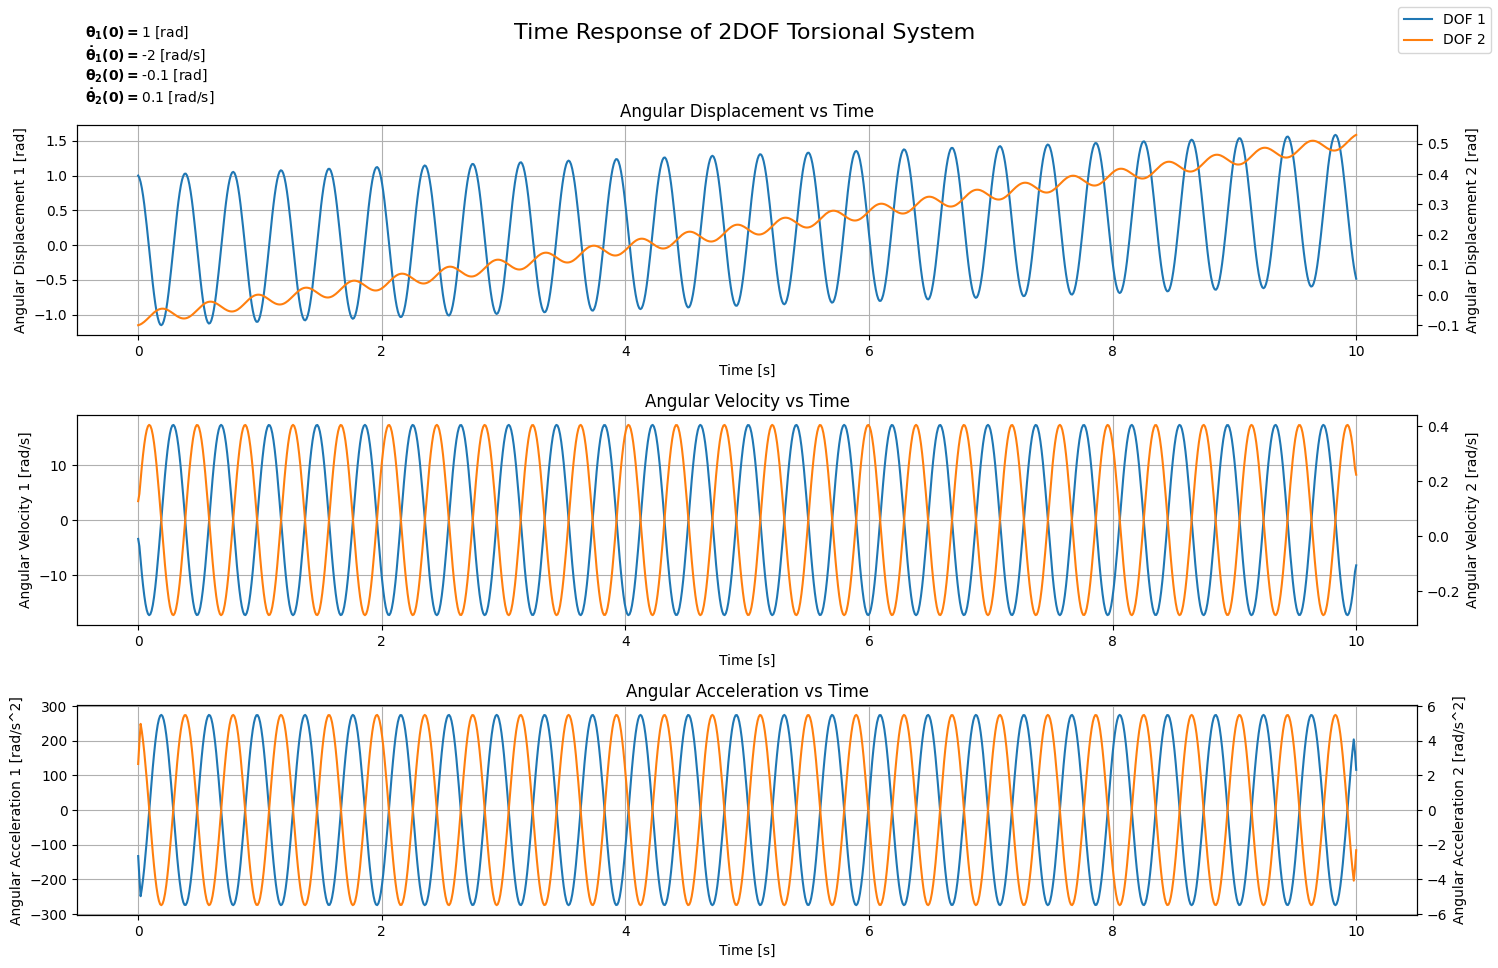

In [6]:
# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(t, theta_1, label='DOF 1')
ax2.plot(t, theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity_1 = np.gradient(theta_1, t, axis=0)
angular_velocity_2 = np.gradient(theta_2, t, axis=0)

ax2 = axes[1].twinx()
axes[1].plot(t, angular_velocity_1)
ax2.plot(t, angular_velocity_2, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration_1 = np.gradient(angular_velocity_1, t, axis=0)
angular_acceleration_2 = np.gradient(angular_velocity_2, t, axis=0)

ax2 = axes[2].twinx()
axes[2].plot(t, angular_acceleration_1)
ax2.plot(t, angular_acceleration_2, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

fig.legend()
fig.text(0.06, 0.9, r"$\mathbf{\theta_1(0) = }$" + f"{theta_0[0]} [rad]" + "\n" + r"$\mathbf{\dot{\theta}_1(0) = }$" + f"{theta_dot_0[0]} [rad/s]" + "\n" + 
         r"$\mathbf{\theta_2(0) = }$" + f"{theta_0[1]} [rad]" + "\n" + r"$\mathbf{\dot{\theta}_2(0) = }$" + f"{theta_dot_0[1]} [rad/s]")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Adding Particular Solution - First Modal Coordinate

In [7]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            # Natural frequency
            self.omega_n = self.calculate_natural_frequency()
            # Mode shapes
            self.phi_1_1 = 1
            self.phi_1_2 = 1
            self.phi_2_1 = 1
            self.phi_2_2 = -self.I_1 / self.I_2
            # Equivalent Inertia - Mode 1
            self.Ieq_1 = self.I_1 + self.I_2
            # Equivalent Inertia - Mode  2
            self.Ieq_2 = self.I_1 + self.I_1**2 / self.I_2
            # Equivalent Stiffness - Mode 2
            self.ceq = self.Ieq_2 * self.omega_n ** 2
        else:
            self.omega_n = None
            self.phi_1_1 = 0
            self.phi_1_2 = 0
            self.phi_2_1 = 0
            self.phi_2_2 = 0
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10,
                               load_type=["poly", "poly"], tau_ext=np.array([[0], [0]], dtype=np.float16)):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        
        # Particular Solution
        # Time array
        t = np.linspace(0, time_span, 1000)
        # Natural frequency
        omega_n = self.omega_n
        if load_type == "poly":
            # TODO: Solve q1 analytically for polynomial
            print(load_type)
        else:
            raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")
        
        # General Solution
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
        A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
        t = np.linspace(0, time_span, 1000)
        theta_1_G = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
        theta_2_G = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [8]:
# Import relevant function from scipy library
from scipy.integrate import cumulative_trapezoid

In [9]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            # Natural frequency
            self.omega_n = self.calculate_natural_frequency()
            # Mode shapes
            self.phi_1_1 = 1
            self.phi_1_2 = 1
            self.phi_2_1 = 1
            self.phi_2_2 = -self.I_1 / self.I_2
            # Equivalent Inertia - Mode 1
            self.Ieq_1 = self.I_1 + self.I_2
            # Equivalent Inertia - Mode  2
            self.Ieq_2 = self.I_1 + self.I_1**2 / self.I_2
            # Equivalent Stiffness - Mode 2
            self.ceq = self.Ieq_2 * self.omega_n ** 2
        else:
            self.omega_n = None
            self.phi_1_1 = 0
            self.phi_1_2 = 0
            self.phi_2_1 = 0
            self.phi_2_2 = 0
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10, load_type=np.array(["poly", "poly"]),
                               tau_ext=np.array([[0], [0]]), dtype=np.float16):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        
        # Group Mode Shapes
        phi = np.array([self.phi_1_1, self.phi_2_1], [self.phi_1_2, self.phi_2_2])

        # Define empty arrays for first modal coordinate
        q_1_t = [] # Complete solution --> Numerical
        qP_1_t = [] # Particular solution --> Analytical

        # Particular Solution
        for i, lt in enumerate(load_type):
            if lt == "measurement":
                # TODO: Solve q1 numerically
                # Time array
                t = tau_ext[i]['time']
                if len(q_1_t) == 0:
                    q_1_t = np.zeros_like(t)
                # Torque array on i-th DOF
                tau_i = tau_ext[i]['load']
                # Modal force
                f_i_1 = phi[0][i] * tau_i
                # First integral
                d_q_i_1 = cumulative_trapezoid(f_i_1, t, initial=0)
                # Second integral
                q_i_1_t = cumulative_trapezoid(d_q_i_1, t, initial=0) / self.Ieq_1
                q_1_t = q_1_t + q_i_1_t
            else:
                # TODO: Check for poly or harmonic and solve q1 analytically
                # Time array
                t = np.linspace(0, time_span, 1000)
                # Natural frequency
                omega_n = self.omega_n
                # Initialize First Modal Solution to 0s
                if len(qP_1_t) == 0:
                    qP_1_t = np.zeros_like(t)
                if lt == "poly":
                    # TODO: Solve q1 analytically for polynomial
                    qP_1_j = np.zeros_like(tau_ext[i])
                    for j, coeff in enumerate(tau_ext[i]):
                        nj = len(tau_ext[i])-1
                        qP_1_j[j] = coeff / ((nj-j+2) * (nj-j+1)) # Coefficients of the first modal coordinate
                        qP_1_t = qP_1_t + phi[0][i] * qP_1_j[j] * t ** (nj-j+2)
                elif lt == "harmonic":
                    # TODO: Solve q1 analytically for harmonic
                    if 'sin' in tau_ext[i]:
                        A_s = tau_ext[i]['sin']['amplitude']
                        omega_s = tau_ext[i]['sin']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(A_s) != len(omega_s):
                            raise Exception("Sin terms: amplitudes and frequencies must have the same length.")
                        qP_1_j = np.zeros_like(A_s) # Sin terms of particular solution initialization
                        for j, (A_j, omega_j) in enumerate(zip(A_s, omega_s)):
                            qP_1_j[j] = -A_j / omega_j**2
                            qP_1_t = qP_1_t + phi[0][i] * qP_1_j[j] * np.sin(omega_j * t)
                    if 'cos' in tau_ext[i]:
                        B_c = tau_ext[i]['cos']['amplitude']
                        omega_c = tau_ext[i]['cos']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(B_c) != len(omega_c):
                            raise Exception("Cos terms: amplitudes and frequencies must have the same length.")
                        qP_1_j = np.zeros_like(B_c) # Sin terms of particular solution initialization
                        for j, (B_j, omega_j) in enumerate(zip(B_c, omega_c)):
                            qP_1_j[j] = -B_j / omega_j**2
                            qP_1_t = qP_1_t + phi[0][i] * qP_1_j[j] * np.cos(omega_j * t)
                else:
                    raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")
                qP_1_t = qP_1_t / self.Ieq_1

                # General Solution
                self.A = np.array([
                    [1, 1, 0, 0, 0, 0, 0, 0],
                    [0, 0, 1, self.omega_n, 0, 0, 0, 0],
                    [0, 0, 0, 0, 1, 1, 0, 0],
                    [0, 0, 0, 0, 0, 0, 1, self.omega_n],
                    [1, 0, 0, 0, -1, 0, 0, 0],
                    [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0, 0, -1, 0],
                    [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
                ])
                self.b = np.array([initial_angle[0] + qP_1_t[0], initial_velocity[0] + np.gradient(qP_1_t)[0], initial_angle[1] + qP_1_t[0], initial_velocity[1] + np.gradient(qP_1_t)[0], 0, 0, 0, 0])
                A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
                t = np.linspace(0, time_span, 1000)
                theta_1_G = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
                theta_2_G = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [10]:
class SDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, inertia=0, stiffness=0):
        self.I = inertia
        self.c = stiffness
        if self.I > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None

    # Method to calculate the natural frequency of the system
    def calculate_natural_frequency(self):
        return np.sqrt(self.c / self.I)

    # Method to simulate the time response of the system
    # NOTE: modified to account for any harmonic excitation
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type="poly", tau_ext=np.array([0], dtype=np.float16)):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertia and stiffness.")
        
        if load_type == "measurement":
            # Time array
            self.t = tau_ext['time']
            # Torque array
            tau_ti = tau_ext['load']
            # Initialize array for angular displacement, velocity, and acceleration to zeros
            self.thetaP_t = np.zeros_like(self.t)
            self.thetaP_t_dot = np.zeros_like(self.t)
            self.thetaP_t_ddot = np.zeros_like(self.t)
            # Iteratively calculate the angular displacement at each time step
            for i in range(len(self.t)-1):
                # Calculate the angular acceleration using the equation of motion
                self.thetaP_t_ddot[i] = (tau_ti[i] - self.c * self.thetaP_t[i]) / self.I
                # Update angular velocity and displacement using finite difference approximation
                dt = self.t[i+1] - self.t[i]
                self.thetaP_t_dot[i+1] = self.thetaP_t_dot[i] + self.thetaP_t_ddot[i] * dt
                self.thetaP_t[i+1] = self.thetaP_t[i] + self.thetaP_t_dot[i+1] * dt
            self.thetaP_t_dot[-1] = self.thetaP_t_dot[-2]
            self.thetaP_t_ddot[-1] = self.thetaP_t_ddot[-2]
        else:
            # Time array
            self.t = np.linspace(0, time_span, 1000)
            if load_type == "poly":
                n = len(tau_ext) - 1 # Polynomial Order
                thetaP_i = np.zeros_like(tau_ext)
                self.thetaP_t = np.zeros_like(self.t)
                self.thetaP_t_dot = np.zeros_like(self.t)
                self.thetaP_t_ddot = np.zeros_like(self.t)
                for i, tau_i in enumerate(tau_ext):
                    if i < 2:
                        thetaP_i[i] = tau_i / self.c # Equation of coefficient for i in [0, 1]
                    else:
                        thetaP_i[i] = (tau_i - self.I*(n-i+2)*(n-i+1)*thetaP_i[i-2]) / self.c # Equation of coefficient for i in [2, n]
                    self.thetaP_t = self.thetaP_t + thetaP_i[i] * self.t ** (n-i) # Equation of particular solution as summation of
                    self.thetaP_t_dot = self.thetaP_t_dot + (n-i) * thetaP_i[i] * self.t ** (n-i-1) if i <= n-1 else self.thetaP_t_dot
                    self.thetaP_t_ddot = self.thetaP_t_ddot + (n-i)*(n-i-1) * thetaP_i[i] * self.t ** (n-i-2) if i <= n-2 else self.thetaP_t_ddot
            elif load_type == "harmonic":
                # Initialize Particular Solution
                self.thetaP_t = np.zeros_like(self.t)
                self.thetaP_t_dot = np.zeros_like(self.t)
                self.thetaP_t_ddot = np.zeros_like(self.t)
                # Sin terms
                if 'sin' in tau_ext:
                    A_s = tau_ext['sin']['amplitude']
                    omega_s = tau_ext['sin']['frequency'] * 2 * np.pi # Convert frequency from Hz to rad/s
                    if len(A_s) != len(omega_s):
                        raise Exception("Sin terms: amplitudes and frequencies must have the same length.")
                    theta_s_i = np.zeros_like(A_s) # Sin terms of particular solution initialization
                    for i, (A_i, omega_i) in enumerate(zip(A_s, omega_s)):
                        theta_s_i[i] = A_i / (self.c - self.I * omega_i ** 2) # Apply derived formula
                        self.thetaP_t = self.thetaP_t + theta_s_i[i] * np.sin(omega_i * self.t) # Add sin terms
                        self.thetaP_t_dot = self.thetaP_t_dot + theta_s_i[i] * omega_i * np.cos(omega_i * self.t)
                        self.thetaP_t_ddot = self.thetaP_t_ddot - theta_s_i[i] * omega_i**2 * np.sin(omega_i * self.t)
                # Cos terms
                if 'cos' in tau_ext:
                    B_c = tau_ext['cos']['amplitude']
                    omega_c = tau_ext['cos']['frequency'] * 2 * np.pi # Convert frequency from Hz to rad/s
                    if len(B_c) != len(omega_c):
                        raise Exception("Cos terms: amplitudes and frequencies must have the same length.")
                    theta_c_j = np.zeros_like(B_c) # Cos terms of particular solution initialization
                    for j, (B_j, omega_j) in enumerate(zip(B_c, omega_c)):
                        theta_c_j[j] = B_j / (self.c - self.I * omega_j ** 2) # Apply derived formula
                        self.thetaP_t = self.thetaP_t + theta_c_j[j] * np.cos(omega_j * self.t) # Add cos terms
                        self.thetaP_t_dot = self.thetaP_t_dot - theta_c_j[j] * omega_j * np.sin(omega_j * self.t)
                        self.thetaP_t_ddot = self.thetaP_t_ddot - theta_c_j[j] * omega_j**2 * np.cos(omega_j * self.t)
            else:
                raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")

        # Calculate the constants A and B based on initial conditions
        self.A = initial_angle - self.thetaP_t[0]  # Adjusting for the particular solution at t=0
        self.B = (initial_velocity - self.thetaP_t_dot[0]) / self.omega_n  # Adjusting for the derivative of the particular solution at t=0
        # General solution for the homogeneous part
        self.thetaG_t = self.A * np.cos(self.omega_n * self.t) + self.B * np.sin(self.omega_n * self.t)
        self.thetaG_t_dot = (-self.A * np.sin(self.omega_n * self.t) + self.B * np.cos(self.omega_n * self.t)) * self.omega_n
        self.thetaG_t_ddot = (-self.A * np.cos(self.omega_n * self.t) - self.B * np.sin(self.omega_n * self.t)) * self.omega_n**2
        # Time response using the analytical solution for the specified load type
        self.theta_t = self.thetaG_t + self.thetaP_t
        self.theta_t_dot = self.thetaG_t_dot + self.thetaP_t_dot
        self.theta_t_ddot = self.thetaG_t_ddot + self.thetaP_t_ddot

In [88]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            # Natural frequency
            self.omega_n = self.calculate_natural_frequency()
            # Mode shapes
            self.phi_1_1 = 1
            self.phi_1_2 = 1
            self.phi_2_1 = 1
            self.phi_2_2 = -self.I_1 / self.I_2
            # Equivalent Inertia - Mode 1
            self.Ieq_1 = self.I_1 + self.I_2
            # Equivalent Inertia - Mode  2
            self.Ieq_2 = self.I_1 + self.I_1**2 / self.I_2
            # Equivalent Stiffness - Mode 2
            self.ceq = self.Ieq_2 * self.omega_n ** 2
        else:
            self.omega_n = None
            self.phi_1_1 = 0
            self.phi_1_2 = 0
            self.phi_2_1 = 0
            self.phi_2_2 = 0
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10,
                               load_type=["poly", "poly"], tau_ext=np.array([[0], [0]]), dtype=np.float16):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        
        # Group Mode Shapes
        phi = np.array([[self.phi_1_1, self.phi_2_1], [self.phi_1_2, self.phi_2_2]])

        # Define empty arrays for first modal coordinate
        self.qP_1_t = [] # Particular solution
        self.qP_1_t_dot = []
        self.qP_1_t_ddot = []

        # Define empty array for second modal coordinate
        self.qP_2_t = [] # Particular solution
        self.qP_2_t_dot = []
        self.qP_2_t_ddot = []

        # Define second modal coordinate as SDOF system
        q2 = SDOFTorsionalSystem(inertia=self.Ieq_2, stiffness=self.ceq)

        # Particular Solution
        for i, lt in enumerate(load_type):
            if lt == "measurement":
                 # Time array
                self.t = tau_ext[i]['time']
                # Torque array on I-TH DOF
                tau_i = tau_ext[i]['load']
                          
                if len(self.qP_1_t) == 0:
                    self.qP_1_t = np.zeros_like(self.t)
                    self.qP_1_t_dot = np.zeros_like(self.t)
                    self.qP_1_t_ddot = np.zeros_like(self.t)
                    self.f_1 = np.zeros((2, len(self.t)))
                
                # Modal force
                self.f_1[i] = phi[0][i] * tau_i
                dd_q_i_1 = self.f_1[i] / self.Ieq_1
                self.qP_1_t_ddot = self.qP_1_t_ddot + dd_q_i_1
                # First integral
                d_q_i_1 = cumulative_trapezoid(dd_q_i_1, self.t, initial=0)
                self.qP_1_t_dot = self.qP_1_t_dot + d_q_i_1
                #d_q_i_1[0] = self.qP_1_0_dot
                # Second integral
                q_i_1_t = cumulative_trapezoid(d_q_i_1, self.t, initial=0)
                #q_i_1_t[0] = self.qP_1_0
                self.qP_1_t = self.qP_1_t + q_i_1_t

                # TODO: Solve q2 numerically
                if len(self.qP_2_t) == 0:
                    self.qP_2_t = np.zeros_like(self.t)
                    self.qP_2_t_dot = np.zeros_like(self.t)
                    self.qP_2_t_ddot = np.zeros_like(self.t)
                    self.f_2 = np.zeros((2, len(self.t)))

                # Modal force
                self.f_2[i] = phi[1][i] * tau_i
                # Solve for second modal coordinate
                q2.simulate_time_response(load_type=lt, tau_ext={'time': self.t, 'load': self.f_2[i]})
                self.qP_2_t = self.qP_2_t + q2.theta_t
                self.qP_2_t_dot = self.qP_2_t_dot + q2.theta_t_dot
                self.qP_2_t_ddot = self.qP_2_t_ddot + q2.theta_t_ddot
            else:
                # Time array
                self.t = np.linspace(0, time_span, 1000)
                # Natural frequency
                omega_n = self.omega_n
                # Initialize First Modal Solution to 0s
                if len(self.qP_1_t) == 0:
                    self.qP_1_t = np.zeros_like(self.t)
                    self.qP_1_t_dot = np.zeros_like(self.t)
                    self.qP_1_t_ddot = np.zeros_like(self.t)
                # Initialize Second Modal Solution to 0s
                if len(self.qP_2_t) == 0:
                    self.qP_2_t = np.zeros_like(self.t)
                    self.qP_2_t_dot = np.zeros_like(self.t)
                    self.qP_2_t_ddot = np.zeros_like(self.t)
                if lt == "poly":
                    qP_1_j = np.zeros_like(tau_ext[i])
                    for j, coeff in enumerate(phi[0][i] * tau_ext[i] / self.Ieq_1):
                        nj = len(tau_ext[i])-1
                        qP_1_j[j] = coeff / ((nj-j+2) * (nj-j+1)) # Coefficients of the first modal coordinate
                        self.qP_1_t = self.qP_1_t + qP_1_j[j] * self.t ** (nj-j+2)
                        self.qP_1_t_dot = self.qP_1_t_dot + (nj-j+2) * qP_1_j[j] * self.t ** (nj-j+1)
                        self.qP_1_t_ddot = self.qP_1_t_ddot + coeff * self.t ** (nj-j)
                    # TODO: Solve q2 analytically for polynomial excitations
                    q2.simulate_time_response(load_type=lt, tau_ext=phi[1][i] * tau_ext[i])
                    self.qP_2_t = self.qP_2_t + q2.theta_t
                    self.qP_2_t_dot = self.qP_2_t_dot + q2.theta_t_dot
                    self.qP_2_t_ddot = self.qP_2_t_ddot + q2.theta_t_ddot
                elif lt == "harmonic":
                    if 'sin' in tau_ext[i]:
                        f_2_sin_load = {'amplitude': phi[1][i] * tau_ext[i]['sin']['amplitude'], 'frequency': tau_ext[i]['sin']['frequency']}
                        A_s = phi[0][i] * tau_ext[i]['sin']['amplitude'] / self.Ieq_1
                        omega_s = tau_ext[i]['sin']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(A_s) != len(omega_s):
                            raise Exception("Sin terms: amplitudes and frequencies must have the same length.")
                        qP_1_j = np.zeros_like(A_s) # Sin terms of particular solution initialization
                        qP_1_j_dot = np.zeros_like(A_s) # Cos terms of particular solution first derivative initialization
                        for j, (A_j, omega_j) in enumerate(zip(A_s, omega_s)):
                            qP_1_j[j] = -A_j / omega_j**2
                            qP_1_j_dot[j] = -A_j / omega_j
                            self.qP_1_t_ddot = self.qP_1_t_ddot + A_j * np.sin(omega_j * self.t)
                            self.qP_1_t_dot = self.qP_1_t_dot + qP_1_j_dot[j] * np.cos(omega_j * self.t)
                            self.qP_1_t = self.qP_1_t + qP_1_j[j] * np.sin(omega_j * self.t)
                    if 'cos' in tau_ext[i]:
                        f_2_cos_load = {'amplitude': phi[1][i] * tau_ext[i]['cos']['amplitude'], 'frequency': tau_ext[i]['cos']['frequency']}                                                
                        B_c = phi[0][i] * tau_ext[i]['cos']['amplitude'] / self.Ieq_1
                        omega_c = tau_ext[i]['cos']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(B_c) != len(omega_c):
                            raise Exception("Cos terms: amplitudes and frequencies must have the same length.")
                        qP_1_j = np.zeros_like(B_c) # Cos terms of particular solution initialization
                        qP_1_j_dot = np.zeros_like(B_c) # Sin terms of particular solution first derivative initialization
                        for j, (B_j, omega_j) in enumerate(zip(B_c, omega_c)):
                            qP_1_j[j] = -B_j / omega_j**2
                            qP_1_j_dot[j] = B_j / omega_j
                            self.qP_1_t_ddot = self.qP_1_t_ddot + B_j * np.cos(omega_j * self.t)
                            self.qP_1_t_dot = self.qP_1_t_dot + qP_1_j_dot[j] * np.sin(omega_j * self.t)
                            self.qP_1_t = self.qP_1_t + qP_1_j[j] * np.cos(omega_j * self.t)
                    # TODO: Solve q2 analytically for harmonic excitations
                    f_2 = {'sin': sin_load, 'cos': cos_load}
                    q2.simulate_time_response(load_type=lt, tau_ext=f_2)
                    self.qP_2_t = self.qP_2_t + q2.theta_t
                    self.qP_2_t_dot = self.qP_2_t_dot + q2.theta_t_dot
                    self.qP_2_t_ddot = self.qP_2_t_ddot + q2.theta_t_ddot
                else:
                    raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")
        

        # Particular Solution - From Modal to Physical Coordinates
        # Angular Displacement
        self.theta_1_P = self.phi_1_1 * self.qP_1_t + self.phi_1_2 * self.qP_2_t
        self.theta_2_P = self.phi_2_1 * self.qP_1_t + self.phi_2_2 * self.qP_2_t
        # Angular Velocity
        self.theta_1_P_dot = self.phi_1_1 * self.qP_1_t_dot + self.phi_1_2 * self.qP_2_t_dot
        self.theta_2_P_dot = self.phi_2_1 * self.qP_1_t_dot + self.phi_2_2 * self.qP_2_t_dot
        # Angular Acceleration
        self.theta_1_P_ddot = self.phi_1_1 * self.qP_1_t_ddot + self.phi_1_2 * self.qP_2_t_ddot
        self.theta_2_P_ddot = self.phi_2_1 * self.qP_1_t_ddot + self.phi_2_2 * self.qP_2_t_ddot
        # General Solution - Physical Coordinates
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0] - self.theta_1_P[0],
                           initial_velocity[0] - self.theta_1_P_dot[0],
                           initial_angle[1] - self.theta_2_P[0],
                           initial_velocity[1] - self.theta_2_P_dot[0],
                           0, 0, 0, 0])
        self.A_1_1, self.A_1_2, self.B_1_1, self.B_1_2, self.A_2_1, self.A_2_2, self.B_2_1, self.B_2_2 = np.linalg.solve(self.A, self.b)
        # Angular Displacement
        self.theta_1_G = self.A_1_1 + self.B_1_1 * self.t + self.A_1_2 * np.cos(self.omega_n * self.t) + self.B_1_2 * np.sin(self.omega_n * self.t)
        self.theta_2_G = self.A_2_1 + self.B_2_1 * self.t + self.A_2_2 * np.cos(self.omega_n * self.t) + self.B_2_2 * np.sin(self.omega_n * self.t)
        # Angular Velocity
        self.theta_1_G_dot = self.B_1_1 - self.A_1_2*self.omega_n * np.sin(self.omega_n * self.t) + self.B_1_2*self.omega_n * np.cos(self.omega_n * self.t)
        self.theta_2_G_dot = self.B_2_1 - self.A_2_2*self.omega_n * np.sin(self.omega_n * self.t) + self.B_2_2*self.omega_n * np.cos(self.omega_n * self.t)
        # Angular Acceleration
        self.theta_1_G_ddot = -(self.A_1_2 * np.cos(self.omega_n * self.t) + self.B_1_2 * np.sin(self.omega_n * self.t))*self.omega_n**2
        self.theta_2_G_ddot = -(self.A_2_2 * np.cos(self.omega_n * self.t) + self.B_2_2 * np.sin(self.omega_n * self.t))*self.omega_n**2
                                
        # Complete Solution - Angular Displacement
        self.theta_1 = self.theta_1_G + self.theta_1_P
        self.theta_2 = self.theta_2_G + self.theta_2_P
        # Complete Solution - Angular Velocity
        self.theta_1_dot = self.theta_1_G_dot + self.theta_1_P_dot
        self.theta_2_dot = self.theta_2_G_dot + self.theta_2_P_dot
        # Complete Solution - Angular Acceleration
        self.theta_1_ddot = self.theta_1_G_ddot + self.theta_1_P_ddot
        self.theta_2_ddot = self.theta_2_G_ddot + self.theta_2_P_ddot

In [89]:
# Define an instance of the model
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)

In [90]:
# Define External Excitations
tau_1 = np.array([1.1, 2], dtype=np.float16) # 1.1*t + 2
tau_2 = np.array([-1, -2.2], dtype=np.float16) # -t - 2.2
# Calculate solution
S.simulate_time_response(load_type=np.array(['poly', 'poly']), tau_ext=[tau_1, tau_2])

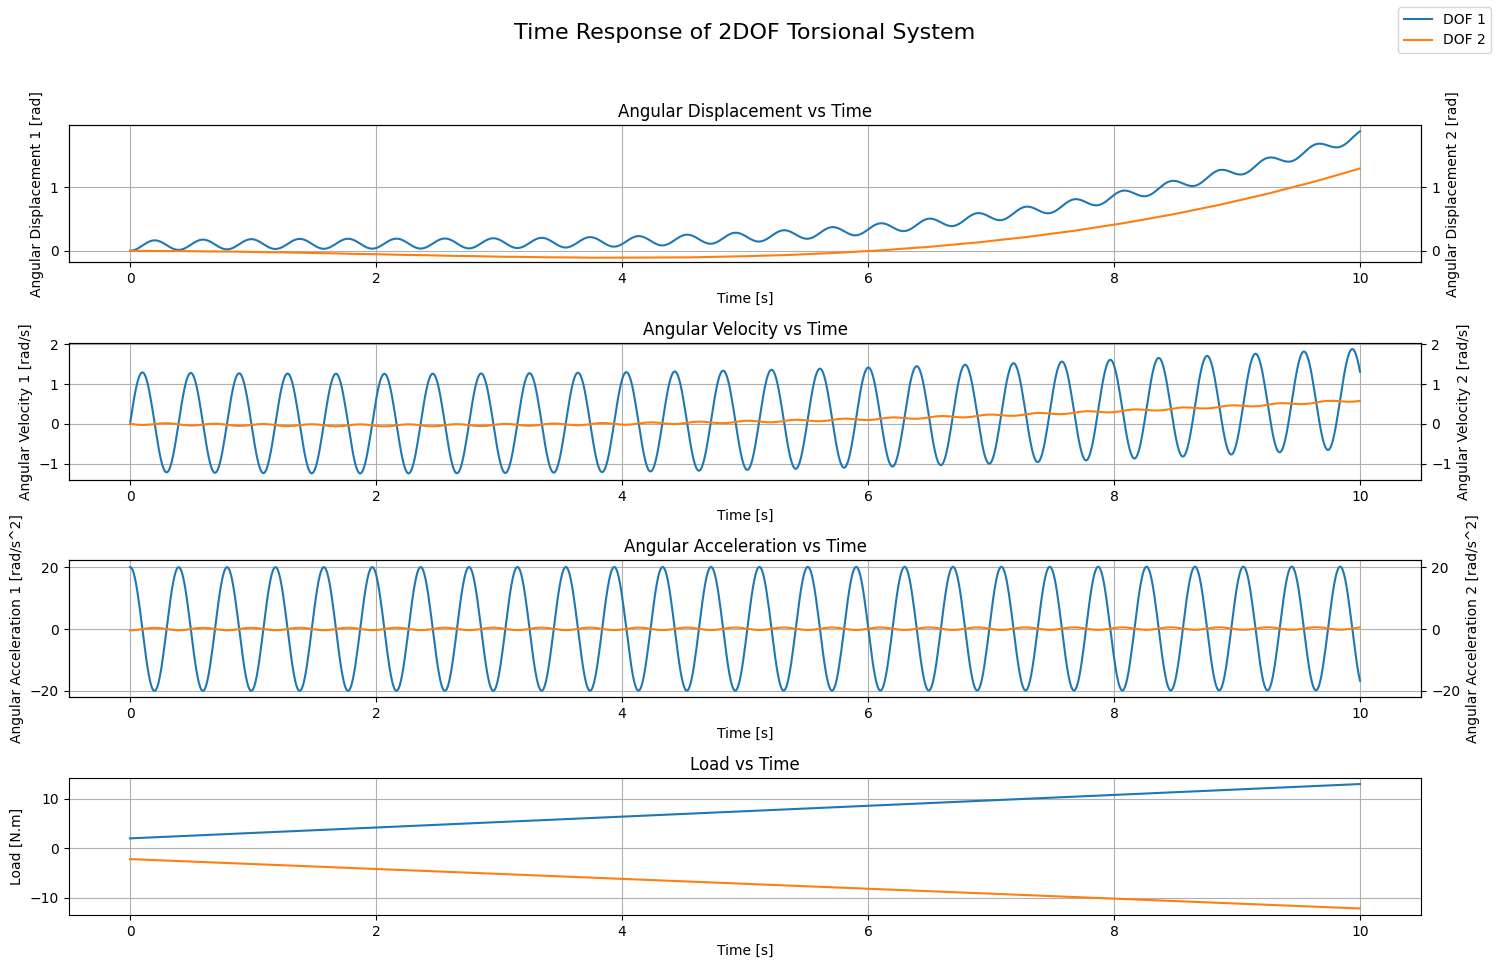

In [91]:
# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(S.t, S.theta_1, label='DOF 1')
ax2.plot(S.t, S.theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
y1_min, y1_max = axes[0].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[0].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

ax2 = axes[1].twinx()
axes[1].plot(S.t, S.theta_1_dot)
ax2.plot(S.t, S.theta_2_dot, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
y1_min, y1_max = axes[1].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[1].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)


ax2 = axes[2].twinx()
axes[2].plot(S.t, S.theta_1_ddot)
ax2.plot(S.t, S.theta_2_ddot, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
y1_min, y1_max = axes[2].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[2].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

# Plot Load
for load in [tau_1, tau_2]:
    load_t = load[0]*t + load[1]
    axes[3].plot(t, load_t)
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Load [N.m]')
axes[3].set_title('Load vs Time')
axes[3].grid(True)

fig.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [92]:
# Define an instance of the model
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)

In [104]:
# Define External Excitations
sin_load = {'amplitude': np.linspace(1,2,5), 'frequency': np.linspace(1,4,5)}
cos_load = {'amplitude': np.linspace(0.4, 1.2,10), 'frequency': np.linspace(8,9, 10)}
tau_1 = {'sin': sin_load, 'cos': cos_load}

sin_load = {'amplitude': np.array([0.6], dtype=np.float16), 'frequency': np.array([15], dtype=np.float16)}
cos_load = {'amplitude': np.array([2], dtype=np.float16), 'frequency': np.array([0.1], dtype=np.float16)}
tau_2 = {'sin': sin_load, 'cos': cos_load}
# Calculate solution
S.simulate_time_response(load_type=np.array(['harmonic', 'harmonic']), tau_ext=[tau_1, tau_2])

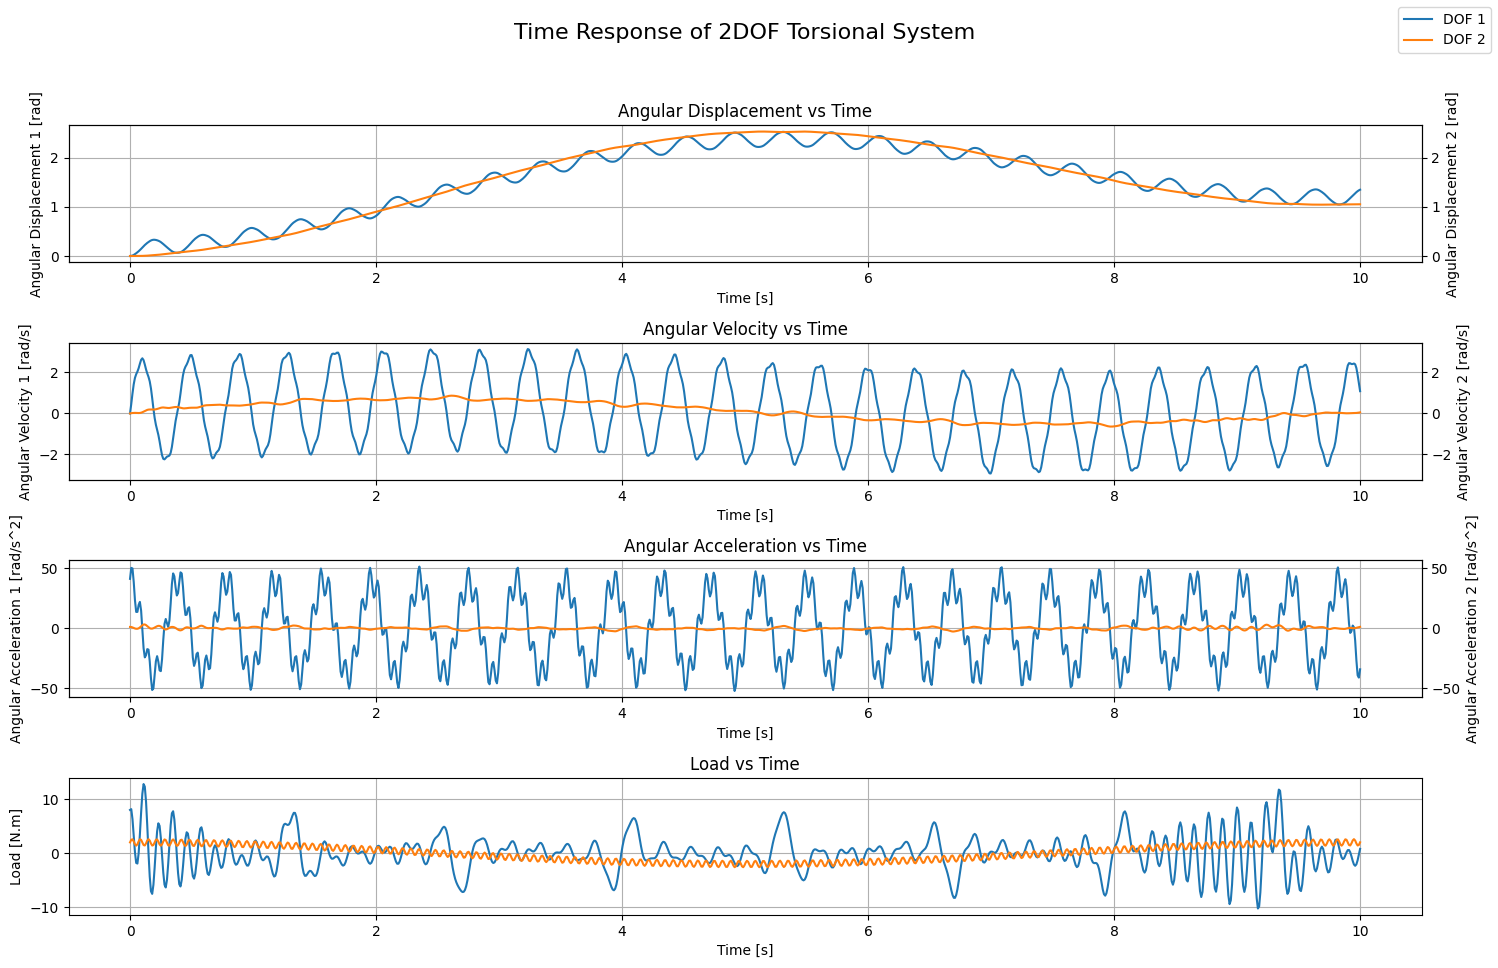

In [105]:
# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(S.t, S.theta_1, label='DOF 1')
ax2.plot(S.t, S.theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
y1_min, y1_max = axes[0].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[0].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

ax2 = axes[1].twinx()
axes[1].plot(S.t, S.theta_1_dot)
ax2.plot(S.t, S.theta_2_dot, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
y1_min, y1_max = axes[1].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[1].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)


ax2 = axes[2].twinx()
axes[2].plot(S.t, S.theta_1_ddot)
ax2.plot(S.t, S.theta_2_ddot, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
y1_min, y1_max = axes[2].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[2].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

# Plot Load
for load in [tau_1, tau_2]:
    load_t = np.zeros_like(S.t)
    for key in load:
        for A, om in zip(load[key]['amplitude'], load[key]['frequency']*2*np.pi):
            if key == 'sin':
                load_t = load_t + A * np.sin(om*S.t)
            elif key == 'cos':
                load_t = load_t + A * np.cos(om*S.t)
    axes[3].plot(S.t, load_t)
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Load [N.m]')
axes[3].set_title('Load vs Time')
axes[3].grid(True)


fig.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [98]:
# Define External Forces
tau_1 = np.array([0.01, 0.005, 0.1], dtype=np.float16) # -0.1t^2 + 0.5t + 1
sin_load = {'amplitude': np.array([0.1], dtype=np.float16), 'frequency': np.array([15], dtype=np.float16)}
cos_load = {'amplitude': np.array([0.6], dtype=np.float16), 'frequency': np.array([0.1], dtype=np.float16)}
tau_2 = {'sin': sin_load, 'cos': cos_load}
# Calculate solution
S.simulate_time_response(load_type=np.array(['poly', 'harmonic']), tau_ext=[tau_1, tau_2])

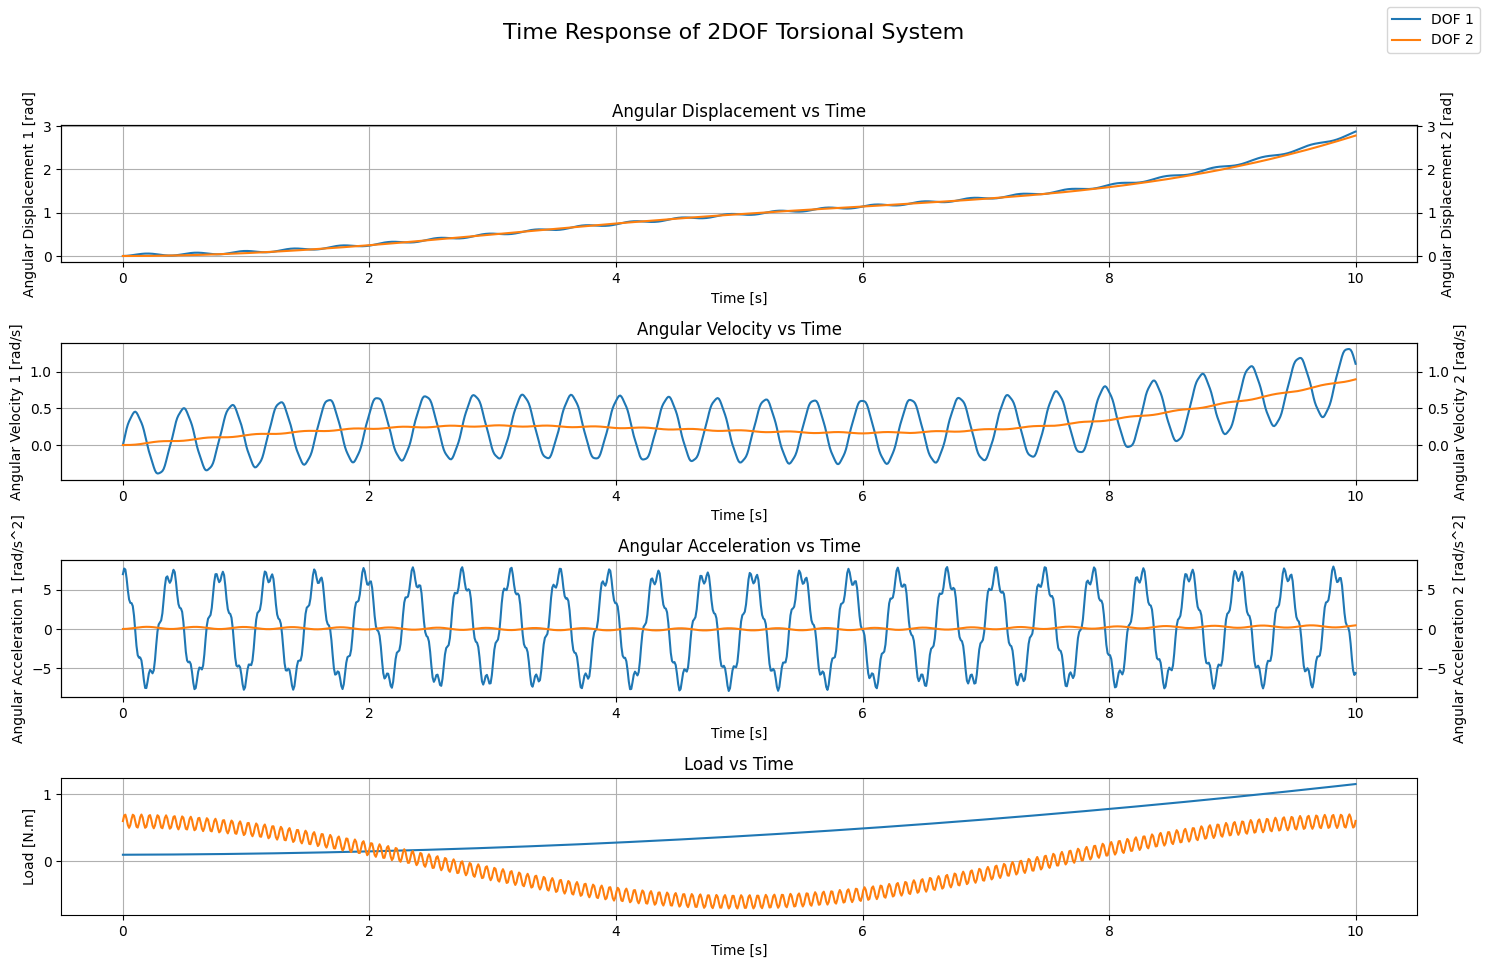

In [99]:
# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(S.t, S.theta_1, label='DOF 1')
ax2.plot(S.t, S.theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
y1_min, y1_max = axes[0].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[0].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

ax2 = axes[1].twinx()
axes[1].plot(S.t, S.theta_1_dot)
ax2.plot(S.t, S.theta_2_dot, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
y1_min, y1_max = axes[1].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[1].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)


ax2 = axes[2].twinx()
axes[2].plot(S.t, S.theta_1_ddot)
ax2.plot(S.t, S.theta_2_ddot, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
y1_min, y1_max = axes[2].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[2].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

# Plot Load
for load in [tau_1, tau_2]:
    load_t = np.zeros_like(t)
    if 'sin' in load:
        for key in load:
            for A, om in zip(load[key]['amplitude'], load[key]['frequency']*2*np.pi):
                if key == 'sin':
                    load_t = load_t + A * np.sin(om*S.t)
                elif key == 'cos':
                    load_t = load_t + A * np.cos(om*S.t)
    else:
        load_t = load[0]*S.t**2 + load[1]*t + load[2]
    axes[3].plot(S.t, load_t)
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Load [N.m]')
axes[3].set_title('Load vs Time')
axes[3].grid(True)

fig.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [100]:
# Simulate time response with a arbitrary excitation: hammer
N = 1000
T = 10
dt = 0.01
time_array = np.linspace(0, T, N) # Time array [s]
dN = int(N//T*dt)
load_array = np.zeros_like(time_array)
load_array[N//T+1:N//T+dN+1] = 1e2
tau_1 = {'time': time_array, 'load': load_array}
tau_2 = {'time': time_array, 'load': np.zeros_like(time_array)}
# Calculate solution
S.simulate_time_response(initial_angle=np.array([0, 0]), initial_velocity=[0, 0], load_type=np.array(['measurement', 'measurement']), tau_ext=[tau_1, tau_2])

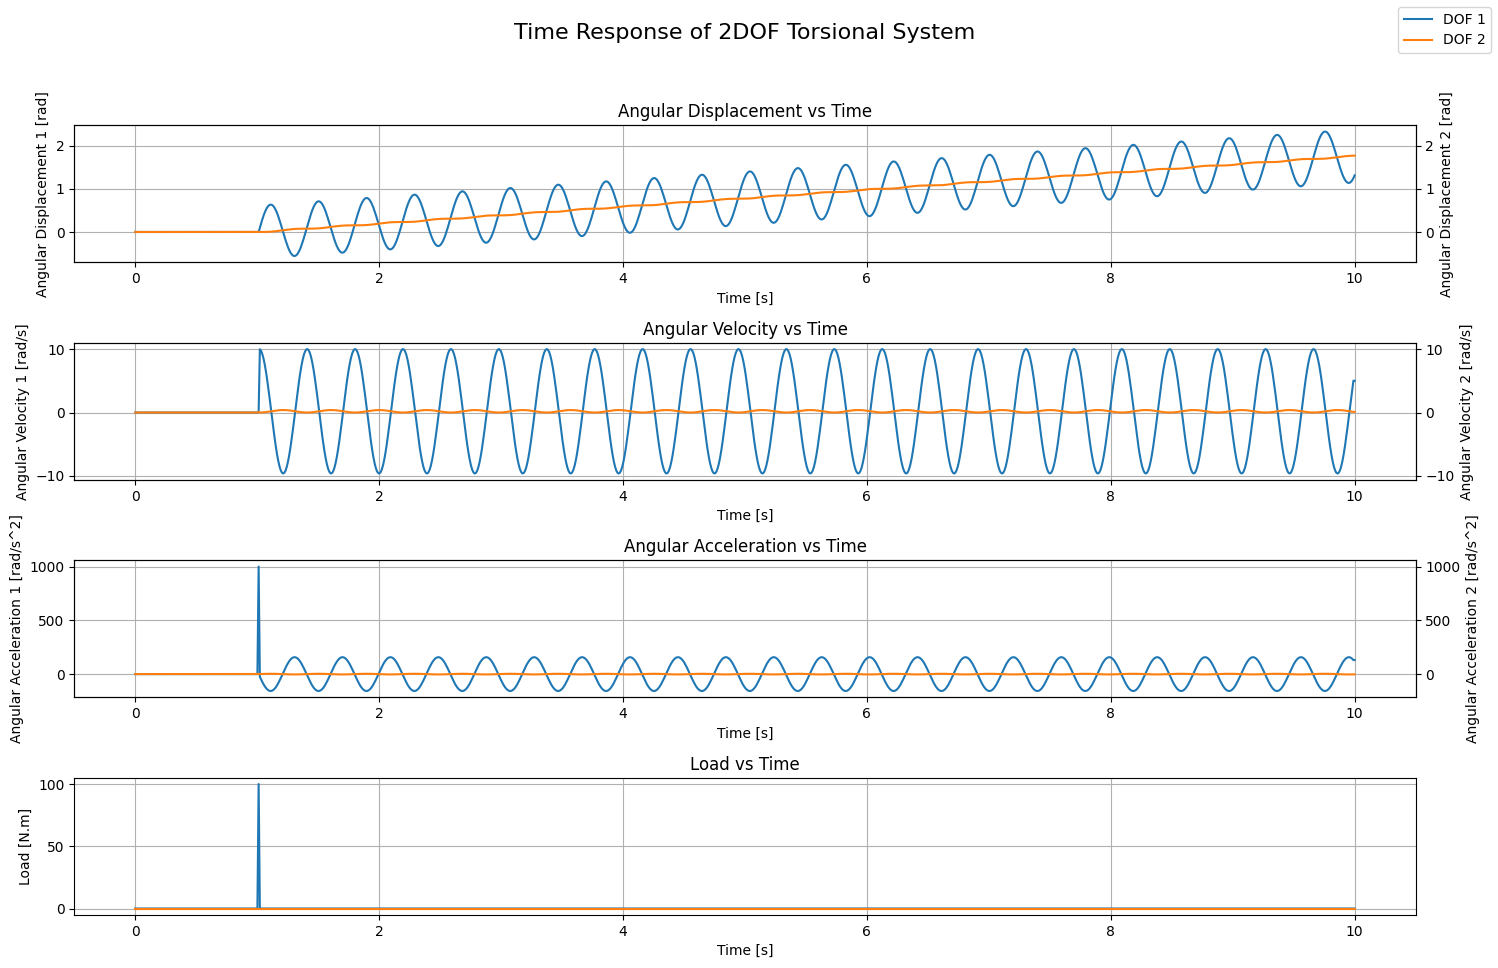

In [101]:
# Plotting the time response
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(S.t, S.theta_1, label='DOF 1')
ax2.plot(S.t, S.theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
y1_min, y1_max = axes[0].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[0].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

ax2 = axes[1].twinx()
axes[1].plot(S.t, S.theta_1_dot)
ax2.plot(S.t, S.theta_2_dot, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
y1_min, y1_max = axes[1].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[1].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)


ax2 = axes[2].twinx()
axes[2].plot(S.t, S.theta_1_ddot)
ax2.plot(S.t, S.theta_2_ddot, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
y1_min, y1_max = axes[2].get_ylim()
y2_min, y2_max = ax2.get_ylim()
ymin = min(y1_min, y2_min)
ymax = max(y1_max, y2_max)
axes[2].set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

# Plot Load
for load in [tau_1, tau_2]:
    axes[3].plot(load['time'], load['load'])
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Load [N.m]')
axes[3].set_title('Load vs Time')
axes[3].grid(True)

fig.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])